## DATA PREPROCESSING

## Imports and data loading

In [ ]:
using_colab = True
if using_colab:
  from google.colab import drive
  drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
file_name='/content/drive/My Drive/MASTER/TFM_Ihona/Preprocessing/dades.xlsx'

In [ ]:
df = pd.read_excel(file_name, sheet_name=0)
df.head()

,id_pacient,NHC,sexe,data_naix,codi_postal,data_def,data_inc_pobl,ltum3,loc3,morf,...,pn,pm,estadi_p,grau_dif,DIAD,MESD,ANYD,CAUSA10,cim10_descr,consum_tabac
0,3,11734238,1,1930-01-30,25195,2012-03-22,2012-03-14,C349,C34,M-80703,...,NaN,NaN,NaN,NaN,22.0,3.0,2012.0,C34,Neoplasia maligna de bronquio y pulmón,No
1,6,11943387,1,1935-01-27,25430,2014-05-05,2013-08-12,C349,C34,M-80703,...,NaN,NaN,NaN,NaN,4.0,5.0,2014.0,C34,Neoplasia maligna de bronquio y pulmón,No
2,8,12150847,2,1936-01-25,25620,2015-02-22,2012-11-15,C349,C34,M-81403,...,NaN,NaN,NaN,NaN,22.0,2.0,2015.0,C34,Neoplasia maligna de bronquio y pulmón,No
3,12,12608694,1,1941-01-21,25500,2013-04-06,2012-11-05,C348,C34,M-81403,...,NaN,NaN,NaN,NaN,6.0,4.0,2013.0,C34,Neoplasia maligna de bronquio y pulmón,No
4,22,13535175,1,1934-01-17,25003,2013-01-02,2012-12-05,C349,C34,M-80423,...,NaN,NaN,NaN,NaN,2.0,1.0,2013.0,C34,Neoplasia maligna de bronquio y pulmón,No


In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1696, 27)


## Data cleaning and preparation

In [ ]:
# Check for missing data
print("\nMissing Data (Count and Percentage):")
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage': missing_percentage}))


Missing Data (Count and Percentage):
               Missing Count  Missing Percentage
id_pacient                 0            0.000000
NHC                        0            0.000000
sexe                       0            0.000000
data_naix                  0            0.000000
codi_postal                0            0.000000
data_def                 693           40.860849
data_inc_pobl              0            0.000000
ltum3                      0            0.000000
loc3                       0            0.000000
morf                       0            0.000000
metode_dx                  0            0.000000
lat                      973           57.370283
t_clinic                1494           88.089623
n_clinic                1498           88.325472
m_clinic                1365           80.483491
estadi_clinic           1375           81.073113
pt                      1535           90.507075
pn                      1540           90.801887
pm                      1543   

In [ ]:
df["sexe"].value_counts()

,count
sexe,
1,1316
2,380


In [ ]:
df["estadi_p"].value_counts()

,count
estadi_p,
IB,36
IIB,18
IA1,16
IIIA,16
IA2,13
IA,12
IIA,8
IV,7
IA3,6


Let's reduce the staging (estadi_p) categories into general subgroups I,II, III and IV. We should have 83 patients in group I, 26 in group II, 20 in group III and 8 in group IV.

In [ ]:
data = {
    'estadi_p': ['IB', 'IIB', 'IA1', 'IIIA', 'IA2', 'IA', 'IIA', 'IV', 'IA3', 'IIIB', 'IVB', None]
}

def categorize_stage(stage):
    if pd.isna(stage):  # Handle NaN values
        return None
    match = re.match(r'^(IV|III|II|I)', stage)  # Ensures IV is prioritized before I
    return match.group(0) if match else stage

# Apply function to create the new column
df['stage_group'] = df['estadi_p'].apply(categorize_stage)

In [ ]:
df['stage_group'].value_counts()

,count
stage_group,
I,83
II,26
III,20
IV,8


In [ ]:
df['stage_group'].isnull().sum()

1559

In [ ]:
df.shape

(1696, 28)

In [ ]:
df[df['estadi_p'] == 'IVB']


,id_pacient,NHC,sexe,data_naix,codi_postal,data_def,data_inc_pobl,ltum3,loc3,morf,...,pm,estadi_p,grau_dif,DIAD,MESD,ANYD,CAUSA10,cim10_descr,consum_tabac,stage_group
1245,41293,12614335,1,1956-09-25,25230,NaT,2016-06-06,C341,C34,M-81403,...,NaN,IVB,NaN,NaN,NaN,NaN,NaN,NaN,Si,IV


In [ ]:
df[df['estadi_p'] == 'IIIB']


,id_pacient,NHC,sexe,data_naix,codi_postal,data_def,data_inc_pobl,ltum3,loc3,morf,...,pm,estadi_p,grau_dif,DIAD,MESD,ANYD,CAUSA10,cim10_descr,consum_tabac,stage_group
975,27991,14192952,1,1937-01-23,25232,NaT,2019-09-03,C341,C34,M-80703,...,X,IIIB,2.0,9.0,9.0,2020.0,C34,Neoplasia maligna de bronquio y pulmón,Si,III
1091,34152,14113654,1,1943-05-28,25006,2020-09-12,2017-02-15,C341,C34,M-80713,...,0,IIIB,NaN,12.0,9.0,2020.0,C34,Neoplasia maligna de bronquio y pulmón,Si,III
1444,44573,16031777,1,1943-10-28,25141,2020-09-16,2018-11-28,C343,C34,M-81403,...,X,IIIB,3.0,16.0,9.0,2020.0,C34,Neoplasia maligna de bronquio y pulmón,Si,III
1680,56936,14871250,1,1951-04-23,25230,2019-10-25,2019-09-03,C341,C34,M-81403,...,X,IIIB,3.0,25.0,10.0,2019.0,C34,Neoplasia maligna de bronquio y pulmón,No,III


In [ ]:
df['consum_tabac'] = df['consum_tabac'].replace('Si', 'Yes')
df['consum_tabac'].value_counts()

,count
consum_tabac,
Yes,1024
No,672


In [ ]:
# Combine day, month, and year columns into a single date column
df['data_def_real'] = pd.to_datetime(
    dict(year=df['ANYD'], month=df['MESD'], day=df['DIAD']),
    errors='coerce'  # Coerce invalid or missing data into NaT
)

# Verify the new column
print(df[['DIAD', 'MESD', 'ANYD', 'data_def_real']].head())

   DIAD  MESD    ANYD data_def_real
0  22.0   3.0  2012.0    2012-03-22
1   4.0   5.0  2014.0    2014-05-04
2  22.0   2.0  2015.0    2015-02-22
3   6.0   4.0  2013.0    2013-04-06
4   2.0   1.0  2013.0    2013-01-02


In [ ]:
# Calculate age at diagnosis
df['age'] = pd.to_datetime(df['data_inc_pobl']).dt.year - pd.to_datetime(df['data_naix']).dt.year
df['age'].describe()

,age
count,1696.000000
mean,68.563679
std,11.494904
min,19.000000
25%,60.000000
50%,69.000000
75%,77.000000
max,97.000000


Let's define a function to categorize age into different groups.

In [ ]:
# Define function to categorize age
def categorize_age(age):
    if age < 50:
        return 1
    elif 50 <= age <= 59:
        return 2
    elif 60 <= age <= 69:
        return 3
    elif 70 <= age <= 79:
        return 4
    else:
        return 5

# Apply function to create new column
df['age_group'] = df['age'].apply(categorize_age).astype(int)

# Display the DataFrame
print(df[['age', 'age_group']].head())

   age  age_group
0   82          5
1   78          4
2   76          4
3   71          4
4   78          4


In [ ]:
df['age_group'].value_counts()

,count
age_group,
3,499
4,493
5,326
2,295
1,83


Now let's adapt and categorize the morphology column.

In [ ]:
# Mapping dictionary
morf_mapping = {
    'M-81403': 'Adenocarcinoma',
    'M-80703': 'Squamous',
    'M-80413': 'Small cell carcinoma',
    'M-80713': 'Epidermoid',
    'M-80003': 'Blastoma',
    'M-80463': ' Non-small cell carcinoma',
}

# Default category for those not in the mapping
default_category = 'Others'

# Apply mapping and fill nulls with the default category:
df['morf_category'] = df['morf'].map(morf_mapping).fillna(default_category)


In [ ]:
df['morf_category'].value_counts()

,count
morf_category,
Adenocarcinoma,636
Squamous,325
Others,227
Small cell carcinoma,157
Epidermoid,127
Blastoma,113
Non-small cell carcinoma,111


In [ ]:
df['morf_category'].isnull().sum()

0

## Column renaming

In [ ]:
# Column rename to English

rename_dict = {
    'id_pacient': 'patient_id',
    'NHC': 'NHC',
    'sexe': 'sex',
    'data_naix': 'date_of_birth',
    'data_def': 'hospital_death_date',
    'data_inc_pobl': 'diagnosis_date',
    'loc3': 'diagnostic',
    'morf_category': 'morphology',
    'metode_dx': 'diagnosis_method',
    'CAUSA10': 'death_code',
    'cim10_descr': 'death_description',
    'consum_tabac': 'tobacco',
    'stage_group': 'stage_group',
    'data_def_real': 'real_death_date',
    'age': 'age',
    'age_group': 'age_group'
}

In [ ]:
# Rename the columns
df.rename(columns=rename_dict, inplace=True)

# Keep only the renamed columns
df = df[list(rename_dict.values())]

# Verify the updated DataFrame
df.columns

Index(['patient_id', 'NHC', 'sex', 'date_of_birth', 'hospital_death_date',
       'diagnosis_date', 'diagnostic', 'morphology', 'diagnosis_method',
       'death_code', 'death_description', 'tobacco', 'stage_group',
       'real_death_date', 'age', 'age_group'],
      dtype='object')

## Data verification

It is possible to see that the hospital death date contains more null values than the official or real death date. Also, there are times when the dates do not align. Therefore, the death date that will be used for the analysis will be the official death date, which is always linked to a death cause, in contrast to the hospital death.

In [ ]:
df[["hospital_death_date", "real_death_date"]].isnull().sum()

,0
hospital_death_date,693
real_death_date,371


In [ ]:
df[["hospital_death_date", "real_death_date"]].head()

,hospital_death_date,real_death_date
0,2012-03-22,2012-03-22
1,2014-05-05,2014-05-04
2,2015-02-22,2015-02-22
3,2013-04-06,2013-04-06
4,2013-01-02,2013-01-02


There are 59 lung cancer diagnosed patients that died according to the hospital but do not contain any death code, so it is not possible to know what did they die from. This patients are therefore discarded by only using the real death date as the death indicator.

In [ ]:
hospital_death_without_code = df[
    (df['hospital_death_date'].notna()) &
    (df['death_code'].isnull())
]

len(hospital_death_without_code)

59

In [ ]:
hospital_death_without_code["diagnostic"].value_counts()

,count
diagnostic,
C34,59


It is possible to see that if we use the offical date of death there are no inconsistencies such as a patient being alive but with a death code or a patient being dead without a code.

In [ ]:
df[["real_death_date", "death_code"]].isnull().sum()

,0
real_death_date,371
death_code,371


In [ ]:
(df[(df['real_death_date'].isnull()) & (df['death_code'].notna())].shape[0])  # Alive with code

0

In [ ]:
(df[(df['real_death_date'].notna()) & (df['death_code'].isnull())].shape[0])  # Dead without code

0

Let's create a new column named "death", that is a boolean indicator that tracks if the patient died (1) or if the patient was alive (0) at the end of the study. A patient is considered death if there is a present date under the real death date column. If the real death date column contains a null, it is assumed that the patient is still alive.

In [ ]:
# Create the 'death' column: 1 if real death date is not null, 0 otherwise
df['death'] = df['real_death_date'].notna().astype(int)
print(df[['death', 'real_death_date']].head())

   death real_death_date
0      1      2012-03-22
1      1      2014-05-04
2      1      2015-02-22
3      1      2013-04-06
4      1      2013-01-02


All the patients from the dataset were diagnosed with lung cancer (because the data was filtered from the database with that condition), but not all the deaths from the dataset may be due to lung cancer.  

In [ ]:
df['death_code'].value_counts() # Patients diagnosed from lung cancer may have died of other conditions.

,count
death_code,
C34,1081
J44,26
C80,18
C61,11
I25,10
...,...
K63,1
K46,1
I63,1


In [ ]:
# Filter rows where the patient died but not of lung cancer
non_lung_cancer_deaths = df[
    (df['death'] == 1) &
    (~df['death_code'].isin(['C34', 'C33']))  # Exclude lung cancer death codes
]

# Count the number of such rows
print(f"Number of patients who died but not of lung cancer: {len(non_lung_cancer_deaths)}")

Number of patients who died but not of lung cancer: 244


In [ ]:
# Filter patients who died but NOT from lung cancer and have a NON-NULL stage_group
non_lung_cancer_deaths_not_null_stage = df[
    (df['death'] == 1) &
    (~df['death_code'].isin(['C34', 'C33'])) &  # Exclude lung cancer death codes
    (df['stage_group'].notna())  # Keep only rows where stage_group is NOT NULL
]

# Count the number of such rows
num_non_lung_cancer_deaths_not_null_stage = len(non_lung_cancer_deaths_not_null_stage)

print(f"Number of patients who died of non-lung cancer with NON-NULL stage_group: {num_non_lung_cancer_deaths_not_null_stage}")


Number of patients who died of non-lung cancer with NON-NULL stage_group: 20


Since we are only interested in patients diagnosed with lung cancer that either died of this condition or survived, we will filter the dataframe accordingly.

Note that the codes C33 and C34 correspond to a malignant tumor of trachea, bronchus or lung.

In [ ]:
df_lung_cancer = df[
    (df['death_code'].isin(['C34', 'C33'])) |  # Patients who died of lung cancer
    ((df['death_code'].isnull()) & (df['diagnostic'].isin(['C34', 'C33'])))  # Alive patients diagnosed with lung cancer
]

# Verify the filtered data
print(df_lung_cancer[['death_code', 'diagnostic', 'death']].value_counts())

death_code  diagnostic  death
C34         C34         1        1081
Name: count, dtype: int64


In [ ]:
# Check the minimum and maximum death dates
min_death_date = df_lung_cancer['real_death_date'].min()
max_death_date = df_lung_cancer['real_death_date'].max()

# Print the results
print(f"Minimum death date: {min_death_date}")
print(f"Maximum death date: {max_death_date}")

Minimum death date: 2012-01-13 00:00:00
Maximum death date: 2021-12-31 00:00:00


In [ ]:
df_lung_cancer['diagnostic'].value_counts() # Total patients diagnosed from lung cancer

,count
diagnostic,
C34,1452


From the 1452 patients that were diagnosed with lung cancer, 1081 of them died and only 371 survived.

In [ ]:
df_lung_cancer['death'].value_counts()

,count
death,
1,1081
0,371


All of the alive patients were diagnosed with lung cancer:

In [ ]:
len(df[
    ((df['death_code'].isnull()) & (~df['diagnostic'].isin(['C34', 'C33'])))  # Alive patients NOT diagnosed with lung cancer
])

0

In [ ]:
# Count the total number of deaths (non-null death_code values)
total_deaths = df['death_code'].notna().sum()

# Count the number of lung cancer deaths (C34 and C33)
lung_cancer_deaths = df['death_code'].isin(['C34', 'C33']).sum()

# Calculate the percentage of lung cancer deaths
lung_cancer_percentage = (lung_cancer_deaths / total_deaths) * 100

# Print the results
print(f"Total deaths: {total_deaths}")
print(f"Lung cancer deaths (C34 and C33): {lung_cancer_deaths}")
print(f"Percentage of lung cancer deaths: {lung_cancer_percentage:.2f}%")

Total deaths: 1325
Lung cancer deaths (C34 and C33): 1081
Percentage of lung cancer deaths: 81.58%


## Exploratory data analysis

In [ ]:
print("Shape of Dataset:", df_lung_cancer.shape)

Shape of Dataset: (1452, 17)


In [ ]:
df_lung_cancer.columns

Index(['patient_id', 'NHC', 'sex', 'date_of_birth', 'hospital_death_date',
       'diagnosis_date', 'diagnostic', 'morphology', 'diagnosis_method',
       'death_code', 'death_description', 'tobacco', 'stage_group',
       'real_death_date', 'age', 'age_group', 'death'],
      dtype='object')

In [ ]:
df_lung_cancer['sex'].value_counts()

,count
sex,
1,1123
2,329


Text(0.5, 1.0, 'Age Distribution of Lung Cancer patients')

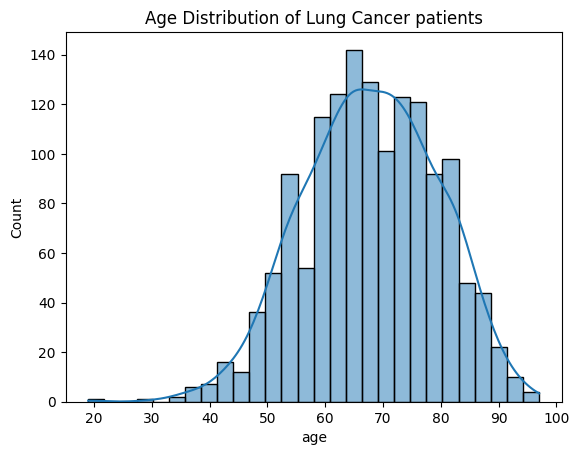

In [ ]:
sns.histplot(data=df_lung_cancer, x="age", kde=True,
             linewidth=1, edgecolor="k")
plt.title("Age Distribution of Lung Cancer patients")

In [ ]:
df["age"].max()

97

In [ ]:
tobacco_by_sex = df_lung_cancer.groupby(['sex', 'tobacco']).size().unstack() # Show patients that smoke by sex
print(tobacco_by_sex)

tobacco   No  Yes
sex              
1        434  689
2        132  197


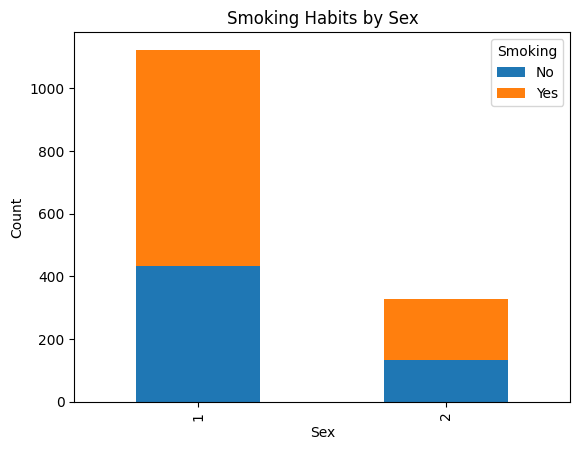

In [ ]:
tobacco_by_sex.plot(kind='bar', stacked=True)
plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Smoking Habits by Sex")
plt.legend(title="Smoking")
plt.show()

In [ ]:
categoric_var = [ "sex", "death", "tobacco", "diagnosis_method", "age_group", "morphology", "stage_group"]
categoric_axis_name  = [ "Sex", "death", "tobacco consumption", "diagnosis method", "Age group", "morphology", "Stage group"]

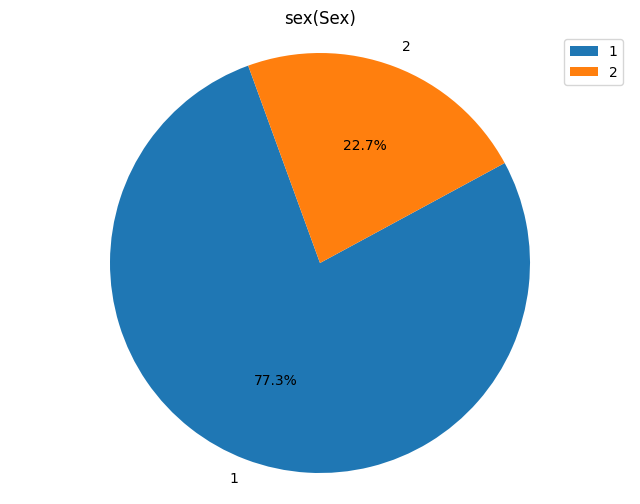

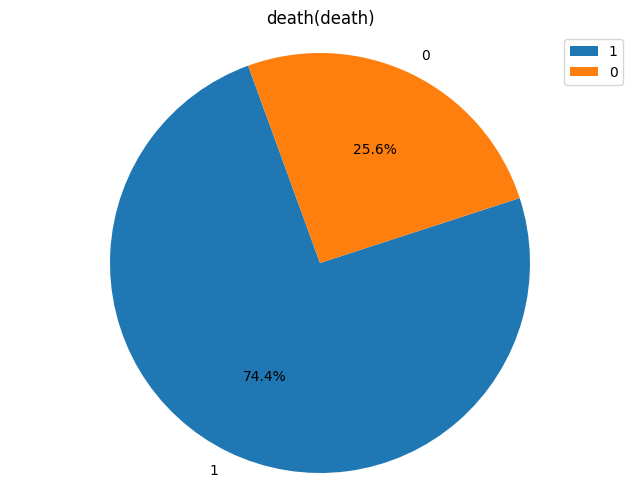

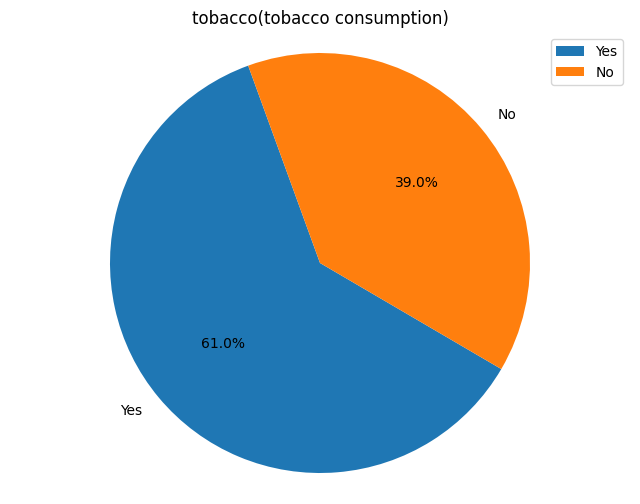

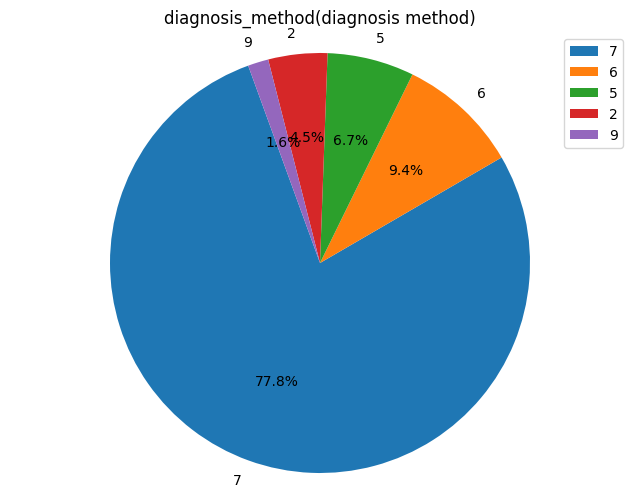

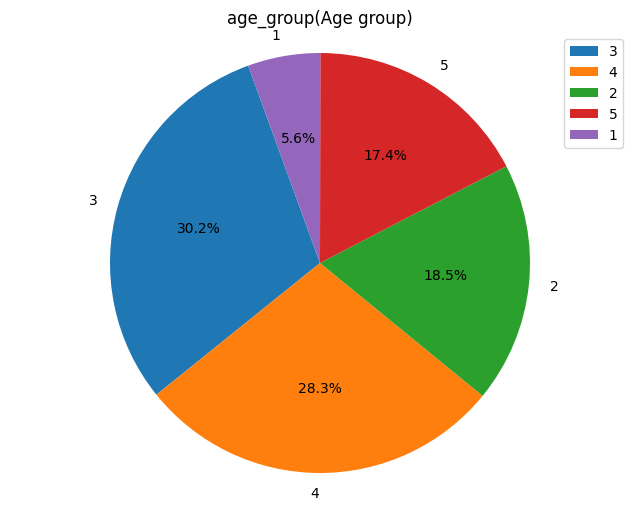

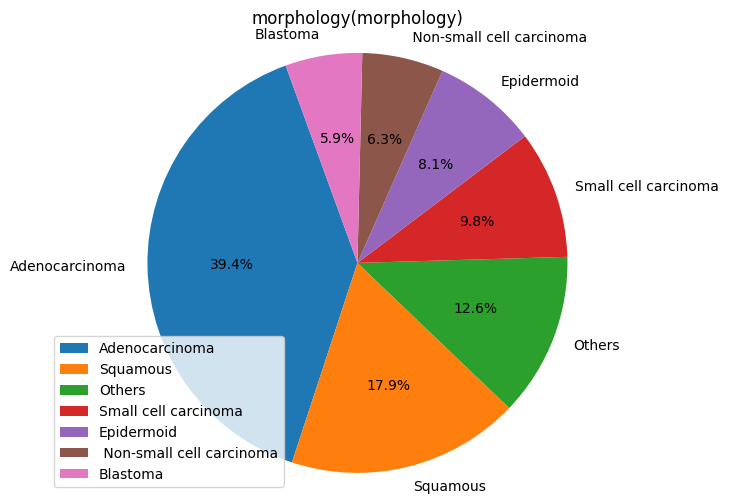

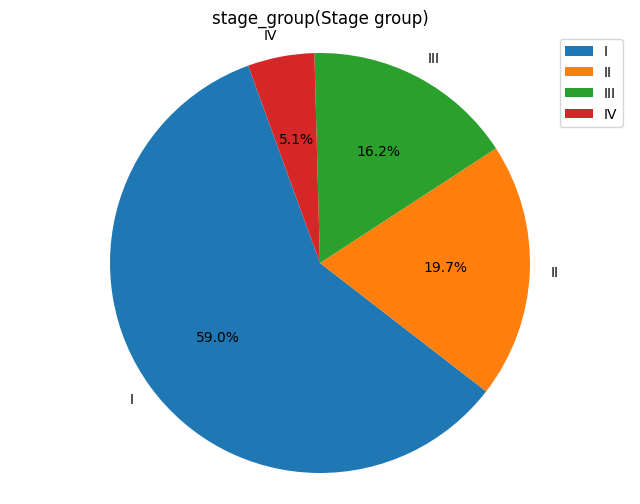

In [ ]:
# Analysis with Pie Chart

for i, z in list(zip(categoric_var, categoric_axis_name)):
    fig, ax = plt.subplots(figsize = (8, 6))

    observation_values = list(df_lung_cancer[i].value_counts().index)  #i referrs to the first variable of the zip: "categoric_var"
    total_observation_values = list(df_lung_cancer[i].value_counts())


    ax.pie(total_observation_values, labels= observation_values, autopct = '%1.1f%%', startangle = 110, labeldistance = 1.1)
    ax.axis("equal") # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.title((i + "(" + z + ")")) # Naming Pie Chart Titles
    plt.legend()
    plt.show()

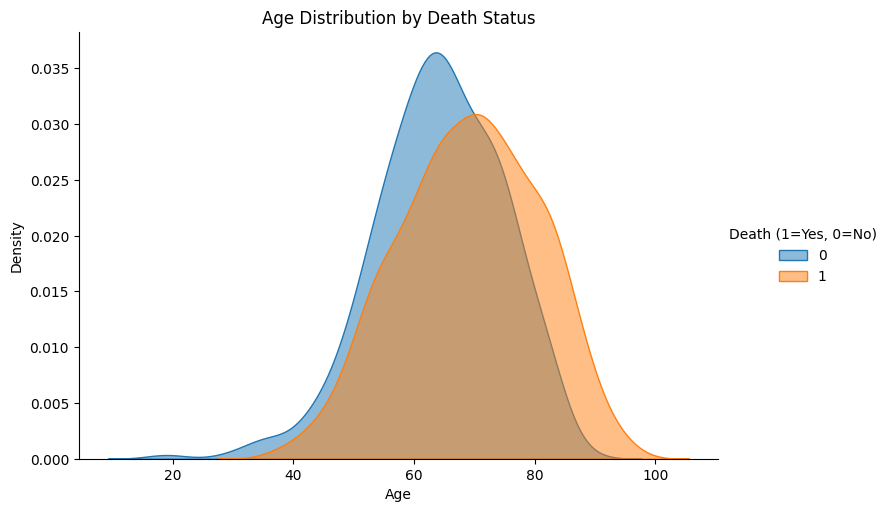

In [ ]:
# Create a FacetGrid to superpose KDEs of death categories on age
g = sns.FacetGrid(df_lung_cancer, hue="death", height=5, aspect=1.5)

# Add KDE plots for age
g.map(sns.kdeplot, "age", fill=True, alpha=0.5)

# Add legend and labels
g.add_legend(title="Death (1=Yes, 0=No)")
plt.title("Age Distribution by Death Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

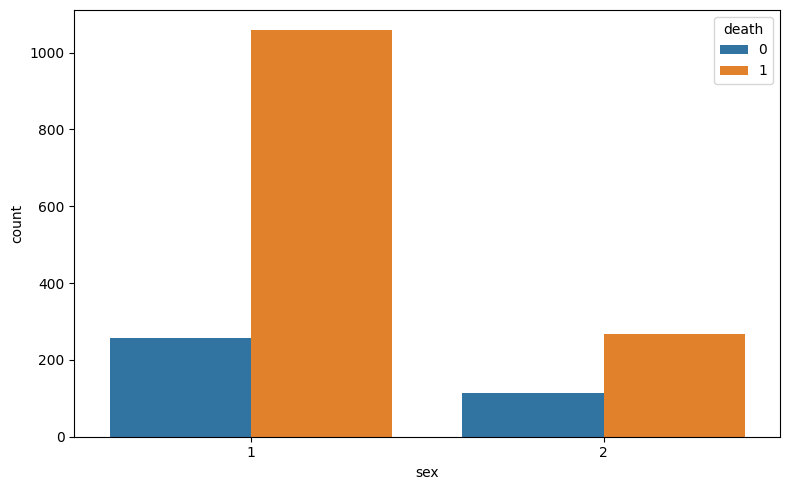

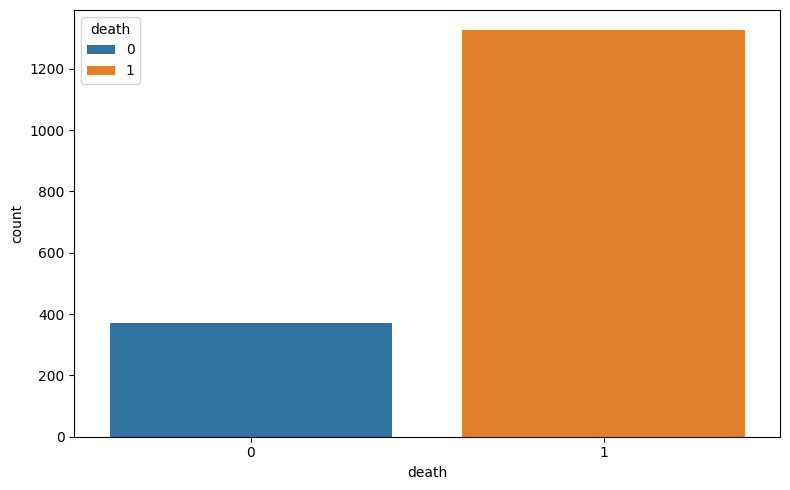

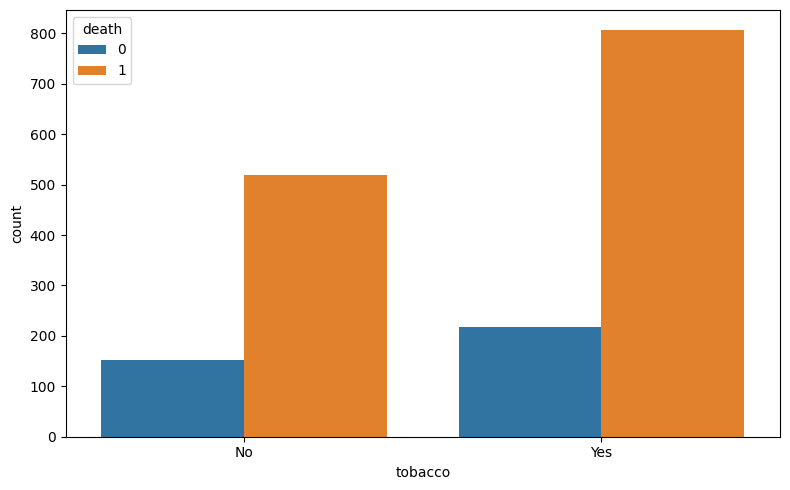

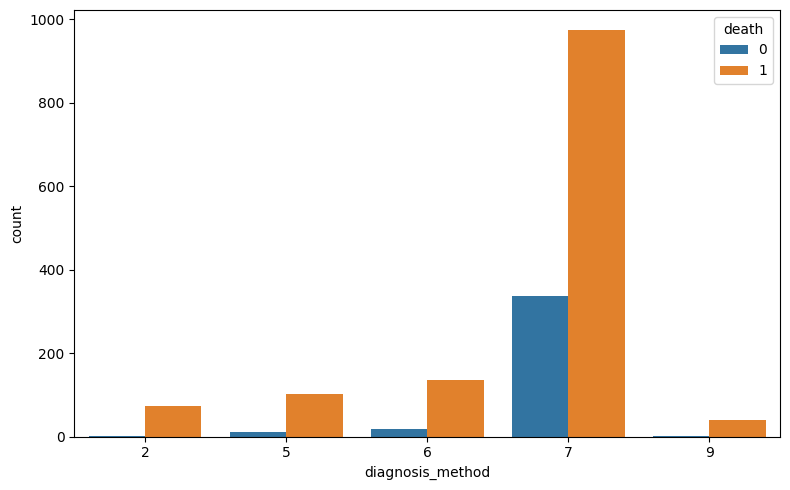

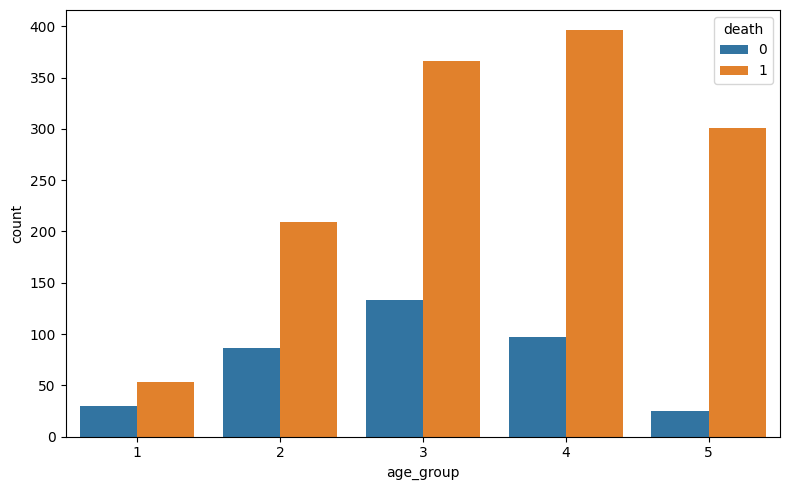

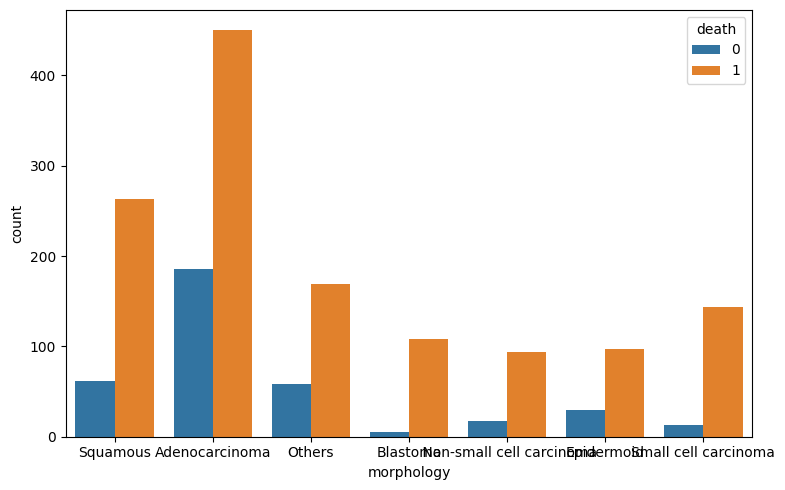

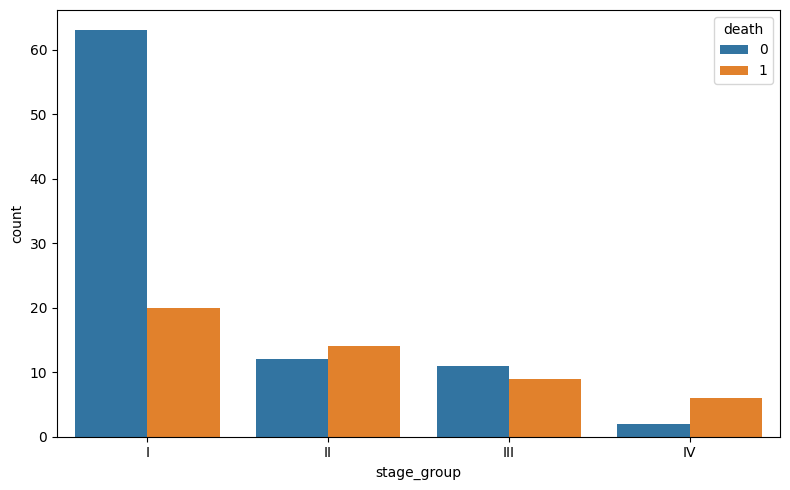

In [ ]:
for i, z in list(zip(categoric_var, categoric_axis_name)):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=i, data=df, hue="death")

    plt.tight_layout()
    plt.show()

## Preparing for survival analysis

We already have a "death" column that indicates whether the patient died or if the data is censored (if the patient did not experience the event of interest at the end of the study, either because they remain alive or due to lost of follow-up). However, we need to create a column (or more than one, depending on our chosen granularity) that represents the time to event (how many time has passed from the diagnosis to the event, which is death). For patients that have died, it will be the difference in months from the death date and the diagnosis date. For censored patients, it will be the difference from the end of study date (31/12/2021) and the diagnosis date.

In [ ]:
import pandas as pd

# Ensure that the date columns are in datetime format
df_lung_cancer['real_death_date'] = pd.to_datetime(df_lung_cancer['real_death_date'])
df_lung_cancer['diagnosis_date'] = pd.to_datetime(df_lung_cancer['diagnosis_date'])

# Define the end of the study date
end_of_study_date = pd.to_datetime('2021-12-31')

# Replace missing death dates with the end of the study date
df_lung_cancer['time_to_event_date'] = df_lung_cancer['real_death_date'].fillna(end_of_study_date)

# Calculate the time to event in days
df_lung_cancer['time_to_event_days'] = (df_lung_cancer['time_to_event_date'] - df_lung_cancer['diagnosis_date']).dt.days

# Convert the time to months
df_lung_cancer['time_to_event_months'] = df_lung_cancer['time_to_event_days'] / 30.4375  # Average days in a month

# Convert the time to years
df_lung_cancer['time_to_event_years'] = df_lung_cancer['time_to_event_days'] / 365.25  # Average days in a year

# Print the resulting DataFrame for verification
print(df_lung_cancer[['diagnosis_date', 'real_death_date', 'time_to_event_date',
                      'time_to_event_days', 'time_to_event_months', 'time_to_event_years']].head())


  diagnosis_date real_death_date time_to_event_date  time_to_event_days  \
0     2012-03-14      2012-03-22         2012-03-22                   8   
1     2013-08-12      2014-05-04         2014-05-04                 265   
2     2012-11-15      2015-02-22         2015-02-22                 829   
3     2012-11-05      2013-04-06         2013-04-06                 152   
4     2012-12-05      2013-01-02         2013-01-02                  28   

   time_to_event_months  time_to_event_years  
0              0.262834             0.021903  
1              8.706366             0.725530  
2             27.236140             2.269678  
3              4.993840             0.416153  
4              0.919918             0.076660  


<ipython-input-29-30d51bec8c9b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lung_cancer['real_death_date'] = pd.to_datetime(df_lung_cancer['real_death_date'])
<ipython-input-29-30d51bec8c9b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lung_cancer['diagnosis_date'] = pd.to_datetime(df_lung_cancer['diagnosis_date'])
<ipython-input-29-30d51bec8c9b>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

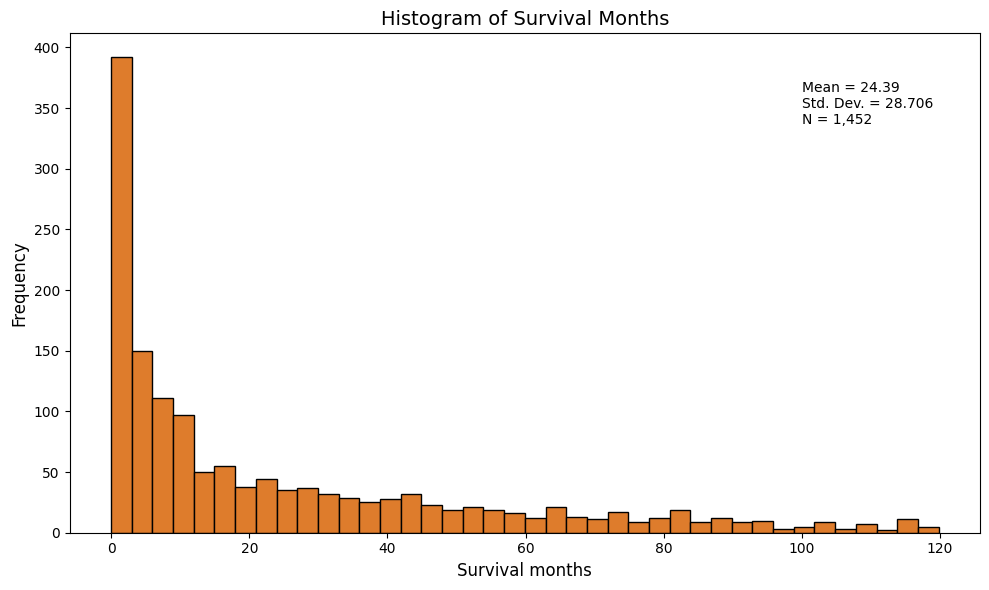

In [ ]:
survival_months = df_lung_cancer['time_to_event_months'].dropna()

mean_val = survival_months.mean()
std_val = survival_months.std()
n_val = survival_months.count()

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(survival_months, bins=40, color='#DE7C2C', edgecolor='black')

plt.xlabel('Survival months', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Survival Months', fontsize=14)

# Statistics to show
stats_text = f"Mean = {mean_val:.2f}\nStd. Dev. = {std_val:.3f}\nN = {n_val:,}"
plt.text(100, max(np.histogram(survival_months, bins=40)[0]) * 0.95, stats_text,
         fontsize=10, verticalalignment='top')

plt.grid(False)
plt.gca()
plt.tight_layout()
plt.show()

In [ ]:
df_lung_cancer.columns

Index(['patient_id', 'NHC', 'sex', 'date_of_birth', 'hospital_death_date',
       'diagnosis_date', 'diagnostic', 'morphology', 'diagnosis_method',
       'death_code', 'death_description', 'tobacco', 'stage_group',
       'real_death_date', 'age', 'age_group', 'death', 'time_to_event_date',
       'time_to_event_days', 'time_to_event_months', 'time_to_event_years'],
      dtype='object')

In [ ]:
df_lung_cancer['tobacco'].value_counts()

,count
tobacco,
Yes,886
No,566


In [ ]:
df_lung_cancer['time_to_event_date'].isnull().sum()

0

In [ ]:
df_lung_cancer['time_to_event_months'].min()
#df_lung_cancer['time_to_event_months'].max()


-0.03285420944558522

There is one case where the date of death happens before the date of diagnosis, causing a negative time to event, which does not make any sense. Therefore, this value is removed.

In [ ]:
df_lung_cancer[df_lung_cancer['time_to_event_months'] < 0]

,patient_id,NHC,sex,date_of_birth,hospital_death_date,diagnosis_date,diagnostic,morphology,diagnosis_method,death_code,...,tobacco,stage_group,real_death_date,age,age_group,death,time_to_event_date,time_to_event_days,time_to_event_months,time_to_event_years
1036,31277,14155868,1,1953-05-14,NaT,2016-09-19,C34,Adenocarcinoma,5,C34,...,Yes,None,2016-09-18,63,3,1,2016-09-18,-1,-0.032854,-0.002738


In [ ]:
df_lung_cancer = df_lung_cancer[
    ~((df_lung_cancer['time_to_event_months'] < 0))
]

In [ ]:
df_lung_cancer['time_to_event_months'].min()

0.03285420944558522

In [ ]:
df_lung_cancer['time_to_event_years'].min()

0.0027378507871321013

In [ ]:
df_lung_cancer['time_to_event_days'].min()

1

Let's keep the interesting columns for the downstreem survival analysis and save the file:

In [ ]:
columns_to_keep_1 = [
    'patient_id', 'NHC', 'sex', 'morphology', 'tobacco', 'age_group', 'stage_group','time_to_event_days', 'time_to_event_months', 'time_to_event_years' ,'death']

df_lung_cancer_stage = df_lung_cancer[columns_to_keep_1] # Keep only the selected columns

df_lung_cancer_stage = df_lung_cancer_stage[df_lung_cancer_stage['stage_group'].notna()] # Keep only those patients that have stage values

# Verify the new DataFrame
print(df_lung_cancer_stage.head())

     patient_id       NHC  sex      morphology tobacco  age_group stage_group  \
177        1763  14043651    1  Adenocarcinoma     Yes          4           I   
225        2425  13972349    1  Adenocarcinoma     Yes          3           I   
243        2666  14124829    2  Adenocarcinoma      No          2           I   
378        4518  14130034    2  Adenocarcinoma     Yes          3           I   
391        5282  13884072    1  Adenocarcinoma     Yes          4          II   

     time_to_event_days  time_to_event_months  time_to_event_years  death  
177                1215             39.917864             3.326489      0  
225                2138             70.242300             5.853525      0  
243                1017             33.412731             2.784394      0  
378                2720             89.363450             7.446954      0  
391                2887             94.850103             7.904175      0  


In [ ]:
df_lung_cancer_stage.shape

(117, 11)

In [ ]:
columns_to_keep_2 = [
    'patient_id', 'NHC', 'sex', 'morphology', 'tobacco', 'age_group', 'time_to_event_days', 'time_to_event_months', 'time_to_event_years' ,'death']

# Keep only the selected columns
df_lung_cancer = df_lung_cancer[columns_to_keep_2]

# Verify the new DataFrame
print(df_lung_cancer.head())


   patient_id       NHC  sex      morphology tobacco  age_group  \
0           3  11734238    1        Squamous      No          5   
1           6  11943387    1        Squamous      No          4   
2           8  12150847    2  Adenocarcinoma      No          4   
3          12  12608694    1  Adenocarcinoma      No          4   
4          22  13535175    1          Others      No          4   

   time_to_event_days  time_to_event_months  time_to_event_years  death  
0                   8              0.262834             0.021903      1  
1                 265              8.706366             0.725530      1  
2                 829             27.236140             2.269678      1  
3                 152              4.993840             0.416153      1  
4                  28              0.919918             0.076660      1  


In [ ]:
df_lung_cancer.columns

Index(['patient_id', 'NHC', 'sex', 'morphology', 'tobacco', 'age_group',
       'time_to_event_days', 'time_to_event_months', 'time_to_event_years',
       'death'],
      dtype='object')

Let's create specific datasets to analyze in the survival analysis.

In [ ]:
# Dataset with only men (sex = 1)
df_lung_cancer_men = df_lung_cancer[df_lung_cancer['sex'] == 1].copy()

# Dataset with only women (sex = 2)
df_lung_cancer_women = df_lung_cancer[df_lung_cancer['sex'] == 2].copy()


In [ ]:
# Verify the sex splitting

print(f"Original dataset size: {df_lung_cancer.shape[0]}")
print(f"Men dataset size: {df_lung_cancer_men.shape[0]}")
print(f"Women dataset size: {df_lung_cancer_women.shape[0]}")


Original dataset size: 1451
Men dataset size: 1122
Women dataset size: 329


In [ ]:
# Dataset with smokers (sex = 1)
df_lung_cancer_smokers = df_lung_cancer[df_lung_cancer['tobacco'] == 'Yes'].copy()

# Dataset with only women (sex = 2)
df_lung_cancer_non_smokers = df_lung_cancer[df_lung_cancer['tobacco'] == 'No'].copy()

In [ ]:
print(f"Original dataset size: {df_lung_cancer.shape[0]}")
print(f"Smokers dataset size: {df_lung_cancer_smokers.shape[0]}")
print(f"Non-smokers dataset size: {df_lung_cancer_non_smokers.shape[0]}")


Original dataset size: 1451
Smokers dataset size: 885
Non-smokers dataset size: 566


Save the different datasets in csv:

In [ ]:
# Save the DataFrame to a CSV file
df_lung_cancer.to_csv('df_lung_cancer.csv', index=False)

In [ ]:
df_lung_cancer_men.to_csv('df_lung_cancer_men.csv', index=False)

In [ ]:
df_lung_cancer_women.to_csv('df_lung_cancer_women.csv', index=False)

In [ ]:
df_lung_cancer_smokers.to_csv('df_lung_cancer_smokers.csv', index=False)

In [ ]:
df_lung_cancer_non_smokers.to_csv('df_lung_cancer_non_smokers.csv', index=False)

In [ ]:
df_lung_cancer_stage.to_csv('df_lung_cancer_stage.csv', index=False)

In [ ]:
# Download the file to local system
from google.colab import files
files.download('df_lung_cancer.csv')
files.download('df_lung_cancer_men.csv')
files.download('df_lung_cancer_women.csv')
files.download('df_lung_cancer_smokers.csv')
files.download('df_lung_cancer_non_smokers.csv')
files.download('df_lung_cancer_stage.csv')




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df['age_group'].value_counts(normalize=True) * 100


,proportion
age_group,
3,29.422170
4,29.068396
5,19.221698
2,17.393868
1,4.893868
